In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#sns.set_theme(style="white")

num_humans = 50
mos_x_human = 5

igd_values = [10, 30, 50, 75, 90]
all_biting_rates = [0.1, 0.2, 0.3, 0.4, 0.6, 0.8, 1.0, 1.5, 2.0, 2.5, 3.0]

results_dir = "./results"


def apply_conversions(df: pd.DataFrame, num_hum: int, num_mos: int) -> pd.DataFrame:
    df = df.copy()

    for col in ["HS", "HM", "HPC"]:
        if col in df.columns:
            df[col] = 100.0 * df[col] / num_hum

    for col in ["MS", "MC", "MPC"]:
        if col in df.columns:
            df[col] = 100.0 * df[col] / num_mos

    if "PI_Humans" in df.columns:
        df["PI_Humans"] *= 100.0

    if "PI_Mosquitoes" in df.columns:
        df["PI_Mosquitoes"] *= 100.0

    return df

def scenario_folder(igd, br, num_humans, mos_x_human):
    return os.path.join(results_dir,f"IGD_{igd}_BR_{br}_NH_{num_humans}_MxH_{mos_x_human}")

def list_replica_files(igd, br, num_humans, mos_x_human):
    folder = scenario_folder(igd, br, num_humans, mos_x_human)
    pattern = os.path.join(folder, "Iteration_proof_*.txt")
    return sorted(glob.glob(pattern))

def load_final_values(metric, igd, br, num_humans, mos_x_human):
    files = list_replica_files(igd, br, num_humans, mos_x_human)
    num_mos = num_humans * mos_x_human
    values = []

    for f in files:
        df = pd.read_csv(f, sep=";")
        df = apply_conversions(df, num_humans, num_mos)

        if "time" in df.columns:
            df = df.sort_values("time")

        if metric not in df.columns:
            continue

        values.append(float(df.iloc[-1][metric]))

    return [v for v in values if np.isfinite(v)]

In [2]:
plt.rcParams.update({"font.size": 6,
                     "axes.labelsize": 8,
                     "xtick.labelsize": 7,
                     "ytick.labelsize": 7,
                     "legend.fontsize": 6,
                     "legend.title_fontsize": 7})

figsize_heatmap = (9/2.54,4/2.54)
figsize_big = (9/2.54,8/2.54)

# __Genetic Diversity Comparison__

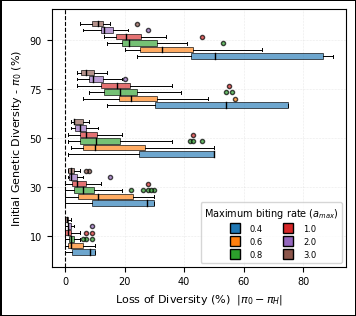

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
igd_values = [10, 30, 50, 75, 90]

selected_biting_rates = [0.4, 0.6, 0.8, 1.0, 2.0, 3.0]

plt.rcParams.update({
    "font.size": 6,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 6,
    "legend.title_fontsize": 7
})

# ----- 1) Build dataframe with initial, final, and loss -----
rows = []
for br in selected_biting_rates:
    for igd in igd_values:
        vals = load_final_values("PI_Humans", igd, br, num_humans, mos_x_human)
        for v in vals:
            rows.append({"BR": br, "IGD": igd, "final": float(v)})

df = pd.DataFrame(rows)
df["loss"] = df["IGD"] - df["final"]   # loss > 0 means diversity decreased

# ----- 2) Color map -----
tab10 = plt.get_cmap("tab10")
br_list = list(selected_biting_rates)
br_colors = {br: tab10(i % 10) for i, br in enumerate(br_list)}

# ----- 3) Treat IGD as categorical: equally spaced positions on Y -----
igd_cats = list(sorted(igd_values))
ypos = np.arange(len(igd_cats))   # 0..K-1 equally spaced

# Grouped boxplots: offsets inside each IGD category
n_br = len(br_list)
group_height = 0.80
box_h = group_height / n_br
offsets = (np.arange(n_br) - (n_br - 1)/2) * box_h

# ----- 4) Plot -----
fig, ax = plt.subplots(figsize=figsize_big)

for j, br in enumerate(br_list):
    # collect data per IGD category for this BR
    data = [df[(df["BR"] == br) & (df["IGD"] == igd)]["loss"].dropna().values
            for igd in igd_cats]

    positions = ypos + offsets[j]

    bp = ax.boxplot(
        data,
        positions=positions,
        widths=box_h * 0.85,
        patch_artist=True,
        showfliers=True,
        whis=1.5,
        manage_ticks=False,
        vert=False   # <-- horizontal boxplots
    )

    # style
    for box in bp["boxes"]:
        box.set_facecolor(br_colors[br])
        box.set_alpha(0.65)
        box.set_edgecolor("black")
        box.set_linewidth(0.7)

    for med in bp["medians"]:
        med.set_color("black")
        med.set_linewidth(1.0)

    for whisk in bp["whiskers"]:
        whisk.set_color("black")
        whisk.set_linewidth(0.7)

    for cap in bp["caps"]:
        cap.set_color("black")
        cap.set_linewidth(0.7)

    for fl in bp["fliers"]:
        fl.set_marker("o")
        fl.set_markersize(3)
        fl.set_markerfacecolor(br_colors[br])
        fl.set_markeredgecolor("black")
        fl.set_alpha(0.7)

# Reference line at 0 loss (now vertical, because loss is on x)
ax.axvline(0, color="black", linestyle="--", linewidth=0.8)

# ----- 5) Categorical y-axis labels -----
ax.set_yticks(ypos)
ax.set_yticklabels([str(v) for v in igd_cats])

ax.set_ylabel(r"Initial Genetic Diversity - $\pi_0$ (%)")
ax.set_xlabel(r"Loss of Diversity (%)  |$\pi_0 - \pi_H$|")

# Legend
handles = [
    Line2D([0], [0], marker='s', linestyle='None',
           markerfacecolor=br_colors[br], markeredgecolor='black',
           markersize=7, label=str(br))
    for br in br_list
]

ax.legend(handles=handles,
          title=r"Maximum biting rate $(a_{max})$",
          frameon=True,
          loc="lower right",
          ncol=2)

ax.grid(True, linestyle=":", linewidth=0.4, alpha=0.5)
plt.tight_layout()
plt.savefig("./Figures/Fig_2_genetic_diversity_horizontal.png", dpi=600, bbox_inches="tight")

fig.patch.set_facecolor("white")
fig.patch.set_edgecolor("black")
fig.patch.set_linewidth(1)
plt.show()

## __Shannon Index__

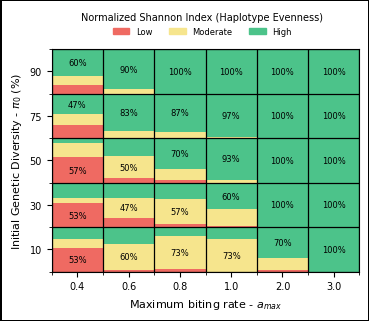

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Estilo como tu ejemplo ---
plt.rcParams.update({
    "font.size": 6,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 6,
    "legend.title_fontsize": 7
})

# Figure size: 9cm x 8cm
fig_w, fig_h = 9/2.54, 8/2.54

selected_biting_rates = [0.4, 0.6, 0.8, 1.0, 2.0, 3.0]
igd_cats = list(sorted(igd_values))
br_cats = list(selected_biting_rates)

# --- 1) Load data ---
rows = []
for br in br_cats:
    for igd in igd_cats:
        vals = load_final_values("SH_Humans", igd, br, num_humans, mos_x_human)
        for v in vals:
            rows.append({"BR": br, "IGD": igd, "sh": float(v)})

df = pd.DataFrame(rows)
df = df[np.isfinite(df["sh"])]
df = df[(df["sh"] >= 0) & (df["sh"] <= 1)]

# --- 2) Categorize ---
def cat3(x):
    if x < 0.3:
        return "Low"
    elif x < 0.7:
        return "Moderate"
    else:
        return "High"

df["cat"] = df["sh"].apply(cat3)
cat_order = ["Low", "Moderate", "High"]

# --- 3) Compute percentages (sum to 100 per IGD×BR) ---
counts = df.groupby(["IGD", "BR", "cat"]).size().unstack(fill_value=0)
totals = counts.sum(axis=1)
pct = counts.div(totals, axis=0) * 100
pct = pct.reindex(columns=cat_order).fillna(0)

# Ensure full grid exists
full_index = pd.MultiIndex.from_product([igd_cats, br_cats], names=["IGD", "BR"])
pct = pct.reindex(full_index, fill_value=0)

# --- helpers: contraste de texto ---
def hex_to_rgb01(h):
    h = h.lstrip("#")
    return tuple(int(h[i:i+2], 16)/255.0 for i in (0, 2, 4))

def rel_luminance(rgb):
    r, g, b = rgb
    return 0.2126*r + 0.7152*g + 0.0722*b

# --- 4) Plot matrix of stacked mini-bars (heatmap-like) ---
fig, ax = plt.subplots(figsize=(fig_w, fig_h))

# Reserva espacio arriba para la leyenda (clave para que NO tape la figura)
# Ajusta top si quieres más/menos espacio (0.80 -> más espacio arriba)
fig.subplots_adjust(top=0.3)

ax.set_facecolor("white")
ax.grid(False)

n_rows = len(igd_cats)
n_cols = len(br_cats)

# Celda exacta 1x1 (evita “cuadricula” de fondo)
bar_w = 1.0
bar_h = 1.0

# Colores más claros + legibles
cat_colors = {
    "Low":      "#ef6a62",  # rojo más claro
    "Moderate": "#f6e58d",  # amarillo suave
    "High":     "#4cc38a"   # verde más claro
}

for r, igd in enumerate(igd_cats):
    for c, br in enumerate(br_cats):
        vals = pct.loc[(igd, br)]

        bottom = 0.0
        seg_ranges = {}

        # segmentos apilados (sin borde blanco para evitar líneas “fantasma”)
        for cat in cat_order:
            h = (vals[cat] / 100.0) * bar_h
            y0 = r + bottom
            y1 = y0 + h
            seg_ranges[cat] = (y0, y1)

            ax.bar(
                x=c,
                height=h,
                bottom=y0,
                width=bar_w,
                color=cat_colors[cat],
                edgecolor="none",
                linewidth=0,
                zorder=2
            )
            bottom += h

        # % en el segmento dominante
        dominant_cat = vals[cat_order].idxmax()
        dom_pct = float(vals[dominant_cat])

        y0, y1 = seg_ranges[dominant_cat]
        if (y1 - y0) > 0.18 * bar_h:
            # En rojo lo dejamos negro como pediste
            if dominant_cat == "Low":
                txt_color = "black"
            else:
                rgb = hex_to_rgb01(cat_colors[dominant_cat])
                txt_color = "white" if rel_luminance(rgb) < 0.55 else "black"

            ax.text(
                c, 0.5*(y0+y1),
                f"{dom_pct:.0f}%",
                ha="center", va="center",
                fontsize=6,   # numeritos un poco más grandes
                color=txt_color,
                zorder=6
            )

# Rejilla negra “fuerte” encima (separación clara)
for x in np.arange(-0.5, n_cols + 0.5, 1.0):
    ax.vlines(x, 0, n_rows, colors="black", linewidth=0.9, zorder=5)
for y in np.arange(0, n_rows + 1, 1.0):
    ax.hlines(y, -0.5, n_cols - 0.5, colors="black", linewidth=0.9, zorder=5)

# Ejes como grilla categórica
ax.set_xlim(-0.5, n_cols - 0.5)
ax.set_ylim(0, n_rows)

ax.set_xticks(range(n_cols))
ax.set_xticklabels([str(b) for b in br_cats])
ax.set_yticks([r + 0.5 for r in range(n_rows)])
ax.set_yticklabels([str(i) for i in igd_cats])

ax.set_xlabel(r"Maximum biting rate - $a_{max}$")
ax.set_ylabel(r"Initial Genetic Diversity - $\pi_0$ (%)")

# Minor ticks en bordes de celdas (las “lineacitas”)
ax.set_xticks(np.arange(-0.5, n_cols, 1.0), minor=True)
ax.set_yticks(np.arange(0, n_rows + 1, 1.0), minor=True)

# Quitar spines exteriores (la rejilla negra ya hace el marco)
for spine in ax.spines.values():
    spine.set_visible(False)

# --- Leyenda fuera del eje (arriba) + explicación de haplotipos ---
handles = [plt.Rectangle((0, 0), 1, 1, color=cat_colors[k]) for k in cat_order]
labels = cat_order

legend_title = (
    "Normalized Shannon Index (Haplotype Evenness)"
)

leg = fig.legend(
    handles, labels,
    title=legend_title,
    ncols=3,
    loc="upper center",
    bbox_to_anchor=(0.55, 0.98),   # arriba, pero en el espacio reservado
    frameon=False
)
#leg.get_frame().set_edgecolor("black")
#leg.get_frame().set_linewidth(0.8)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(.8)
    spine.set_color("black")
    
#ax.tick_params(axis='both', which='major', direction='out', length=2, width=0.7, pad=2)

# tight_layout pero dejando intacta el área superior de la leyenda
plt.tight_layout(pad=0.3, rect=[0, 0, 1, 0.85])

plt.savefig("./Figures/Fig_2_SH_stacked_category_matrix.png", dpi=600, bbox_inches="tight")

# Borde del canvas completo
fig.patch.set_facecolor("white")
fig.patch.set_edgecolor("black")
fig.patch.set_linewidth(1)
plt.show()